In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
file_path = "/content/sample_data/food_calories.json"

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

df.head()

,food_item,grams,calories
0,Artichoke,128.0,60
1,Arugula,2.0,1
2,Asparagus,12.0,2
3,Aubergine,458.0,115
4,Beetroot,82.0,35


In [12]:
print("Number of samples:", df.shape[0])
print("Number of columns:", df.shape[1])

# Since calories is the target, the remaining columns are input features
print("Number of input features:", df.shape[1] - 1)

print("\nColumns:")
print(df.columns.tolist())

Number of samples: 562
Number of columns: 3
Number of input features: 2

Columns:
['food_item', 'grams', 'calories']


In [14]:
print(df.dtypes)

print("\nTarget variable:")
print("calories -> numeric, continuous")

print("\nInput features:")
print("food_item -> categorical/text")
print("grams -> numeric")

food_item     object
grams        float64
calories       int64
dtype: object

Target variable:
calories -> numeric, continuous

Input features:
food_item -> categorical/text
grams -> numeric


In [15]:
print("Missing values:")
print(df.isnull().sum())

print("\nPercentage missing:")
print(df.isnull().mean() * 100)

Missing values:
food_item     0
grams        49
calories      0
dtype: int64

Percentage missing:
food_item    0.000000
grams        8.718861
calories     0.000000
dtype: float64


In [16]:
df.describe()

,grams,calories
count,513.000000,562.000000
mean,162.846004,229.669039
std,160.459051,232.303786
min,2.000000,1.000000
25%,67.000000,70.000000
50%,136.000000,160.500000
75%,227.000000,328.500000
max,2301.000000,2209.000000


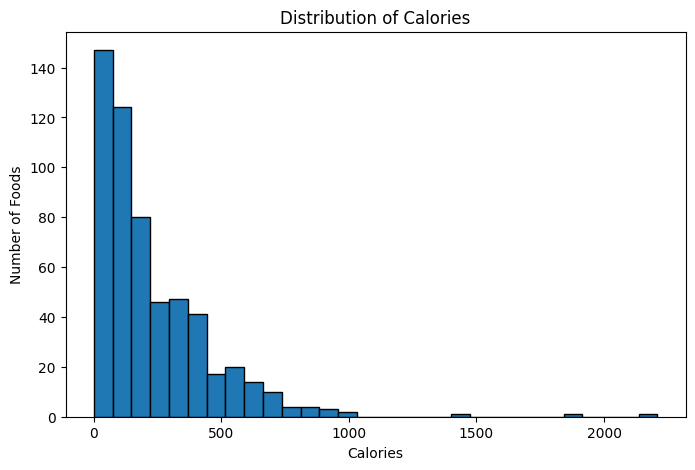

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(df["calories"], bins=30, edgecolor="black")

plt.xlabel("Calories")
plt.ylabel("Number of Foods")
plt.title("Distribution of Calories")

plt.show()

Data is RIGHT skewed.

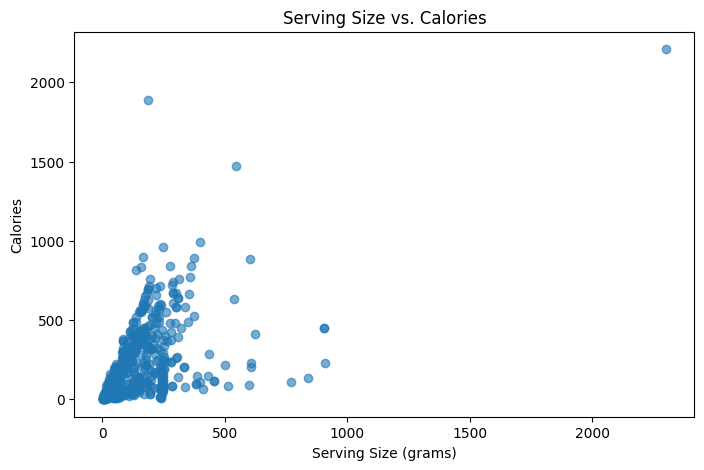

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["grams"], df["calories"], alpha=0.6)

plt.xlabel("Serving Size (grams)")
plt.ylabel("Calories")
plt.title("Serving Size vs. Calories")

plt.show()

In [20]:
correlation = df[["grams", "calories"]].corr()

print(correlation)

             grams  calories
grams     1.000000  0.489094
calories  0.489094  1.000000


In [21]:
print("Duplicate rows:", df.duplicated().sum())

print("Repeated food names:")
print(df[df["food_item"].duplicated(keep=False)]
      .sort_values("food_item")
      .head(30))

Duplicate rows: 15
Repeated food names:
                food_item  grams  calories
67                Avocado  200.0       320
453               Avocado  200.0       320
454                Banana  125.0       111
68                 Banana  125.0       111
197            Brown Rice  195.0       757
126            Brown Rice  185.0       670
19         Collard Greens   36.0        12
139        Collard Greens   45.0        13
375  Durum Wheat Semolina   56.0       222
205  Durum Wheat Semolina   30.0       119
149        Fish and Chips  300.0       585
522        Fish and Chips  300.0       585
464                 Guava   55.0        37
83                  Guava   55.0        37
466             Jackfruit  151.0       143
84              Jackfruit  151.0       143
86                   Kiwi  183.0       112
467                  Kiwi  183.0       112
90       Mandarin Oranges   88.0        47
470      Mandarin Oranges   90.0        48
91                  Mango  336.0       202
471           